# Ce que les capteurs disent et que le modèle n'écoute pas — version pas à pas

Même contenu que `02_ameliorations.ipynb`, découpé plus finement : une idée par cellule, des
commentaires courts. Les résultats sont les mêmes.

Le premier carnet a reproduit une calibration de référence. Le résultat était honnête mais
modeste, et une part importante de l'erreur restante était un **biais** — c'est-à-dire la part
qui ne dit rien de la dynamique.

Ce carnet prend le problème par l'autre bout. Plutôt que de raffiner le modèle de consommation,
il regarde les **conditions aux limites** : ce que le réseau reçoit, ce qu'il stocke, et comment
le modèle en rend compte.

| | levier | mesure utilisée |
|---|---|---|
| 1 | l'état réel de la pompe | débitmètre de la pompe |
| 2 | l'ancrage du niveau du réservoir | capteur de niveau |
| 3 | la section réelle du réservoir | trajectoire simulée du niveau |
| 4 | le niveau de la demande | bilan de masse aux débitmètres d'entrée |

Ce qu'ils valent, annoncé d'avance :

* **1 et 2** transforment le résultat, et ils sont indissociables ;
* **4** corrige un biais sans rien changer à la dynamique ;
* **3** ne donne rien — et la raison pour laquelle il ne donne rien est la partie la plus utile
  du carnet.

Deux derniers paragraphes reviennent sur les rugosités et montrent qu'elles ne sont **pas
identifiables** sur ce réseau.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from calibration import reseau as R, profils as P, rugosite as U, ameliorations as A, diagnostics as G

plt.rcParams.update({"figure.figsize": (10, 3.2), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})

ANNEE = 2018
DEBUT = 181 * R.PAS_JOUR        # on ÉVALUE en juillet
N_PAS = 7 * R.PAS_JOUR
DEBUT_ENTR = 0                  # on AJUSTE sur la semaine 1 : voir le §6
N_ENTR = 2 * R.PAS_JOUR

In [2]:
R.verifier_donnees(ANNEE)
wn = R.charger_modele(duree_h=24)
noeuds = wn.junction_name_list
horo = R.horodatage(ANNEE)
mesure = R.charger_pressions(ANNEE).to_numpy()[DEBUT:DEBUT + N_PAS]
niveau = R.charger_niveau(ANNEE).to_numpy()
debits = R.charger_debits(ANNEE)

In [3]:
formes = P.formes_par_categorie(wn, ANNEE)           # le modèle de demande du carnet 1 (~15 s)
D_calibre, _ = P.demandes_calibrees(wn, ANNEE, formes)
print("prêt")

prêt


## 1. La pompe suit une consigne, pas la réalité

Le fichier pilote la pompe par deux contrôles sur le niveau du réservoir :

```
LINK PUMP_1 CLOSED IF NODE T1 ABOVE 3.9000
LINK PUMP_1 OPEN   IF NODE T1 BELOW 2.4000
```

C'est une règle plausible, et c'est une **hypothèse**. La vraie pompe est commandée autrement, et
son débit est mesuré : on peut donc comparer l'hypothèse à la réalité au lieu de la supposer.

In [4]:
statut_mesure = A.statut_pompe(ANNEE)

def statut_simule(n=N_PAS):
    # relit l'état de la pompe décidé par les contrôles du modèle
    D = D_calibre[DEBUT:DEBUT + n + 1]
    out = R.simuler(D, noeuds, n,
                    lambda res, w, a, b: res.link["status"]["PUMP_1"].to_numpy()[:b - a],
                    tranche_jours=7, niveau0=float(niveau[DEBUT]), verbeux=False)
    return np.concatenate(out)

In [5]:
st_sim = statut_simule()
st_mes = statut_mesure[DEBUT:DEBUT + N_PAS]

print(f"pompe en marche : {st_mes.mean():.1%} du temps mesuré, {st_sim.mean():.1%} simulé")
print(f"basculements sur la fenêtre : {len(A.transitions(st_mes))} mesurés, "
      f"{len(A.transitions(st_sim))} simulés")
print(f"états en désaccord : {(st_sim != st_mes).mean():.1%} des pas")

pompe en marche : 65.0% du temps mesuré, 49.5% simulé
basculements sur la fenêtre : 14 mesurés, 14 simulés
états en désaccord : 22.5% des pas


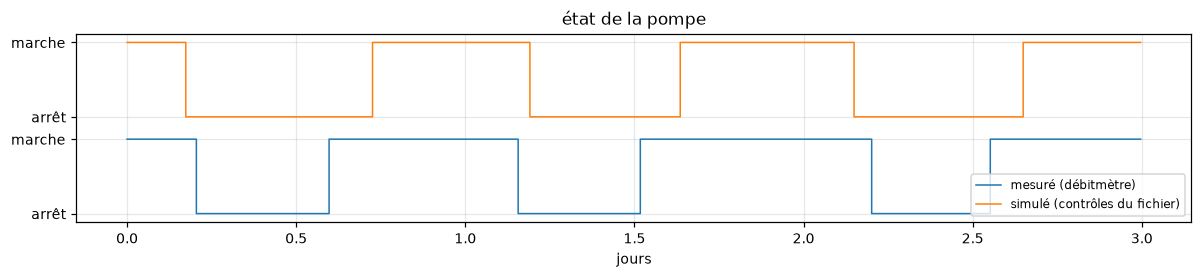

In [6]:
fig, ax = plt.subplots(figsize=(11, 2.6))
j = np.arange(3 * R.PAS_JOUR) / R.PAS_JOUR
ax.step(j, st_mes[:len(j)], lw=1.0, label="mesuré (débitmètre)")
ax.step(j, st_sim[:len(j)] + 1.3, lw=1.0, label="simulé (contrôles du fichier)")
ax.set_yticks([0, 1, 1.3, 2.3]); ax.set_yticklabels(["arrêt", "marche", "arrêt", "marche"])
ax.set_xlabel("jours"); ax.legend(fontsize=8); ax.set_title("état de la pompe")
fig.tight_layout()

Le modèle se trompe d'état de pompe **un peu plus d'un pas sur cinq**. Et le nombre de
basculements est pourtant le bon — 14 contre 14 : ce n'est pas la fréquence qui cloche, c'est le
moment et la durée. La vraie pompe tourne 65 % du temps, la simulée 49,5 %.

Reste à savoir ce que ça coûte. Combien vaut la pompe, en mètres de pression ?

In [7]:
# Que vaut la pompe, en mètres de pression, dans les données mesurées ?
p_mes = R.charger_pressions(ANNEE).to_numpy()
marche = statut_mesure.astype(bool)
entrant = (debits["p227"] + debits["p235"]).to_numpy()

In [8]:
print(f"débit entrant : {entrant[marche].mean():.0f} m³/h pompe en marche, "
      f"{entrant[~marche].mean():.0f} m³/h à l'arrêt "
      f"(+{100 * (entrant[marche].mean() / entrant[~marche].mean() - 1):.0f} %)")
print(f"la pompe prélève à elle seule {debits['PUMP_1'][marche].mean():.0f} m³/h, soit "
      f"{100 * debits['PUMP_1'][marche].mean() / entrant[marche].mean():.0f} % de ce qui entre")

débit entrant : 217 m³/h pompe en marche, 178 m³/h à l'arrêt (+22 %)
la pompe prélève à elle seule 44 m³/h, soit 20 % de ce qui entre


In [9]:
print(f"\npression moyenne aux 33 capteurs : {p_mes[marche].mean():.3f} m en marche, "
      f"{p_mes[~marche].mean():.3f} m à l'arrêt "
      f"(écart {p_mes[marche].mean() - p_mes[~marche].mean():+.3f} m)")


pression moyenne aux 33 capteurs : 46.099 m en marche, 46.452 m à l'arrêt (écart -0.353 m)


In [10]:
ecart = pd.Series(p_mes[marche].mean(axis=0) - p_mes[~marche].mean(axis=0),
                  index=R.capteurs()["pressure"])
print("\ncapteurs les plus sensibles à l'état de la pompe :")
print(ecart.sort_values().head(4).round(3).to_string())


capteurs les plus sensibles à l'état de la pompe :
n54    -0.913
n410   -0.781
n429   -0.772
n342   -0.582


### Lecture

Voilà le mécanisme, mesuré et non supposé. La pompe n'est pas un détail du réservoir : elle
prélève **un cinquième** de tout ce qui entre dans le réseau.

Quand elle démarre, le débit dans les conduites de transport augmente d'autant, la perte de
charge le long de ces conduites augmente avec, et **toutes** les pressions descendent — d'un
tiers de mètre en moyenne, de près d'un mètre près de l'arrivée.

Se tromper d'état un pas sur cinq revient donc à injecter cet écart dans le résidu un pas sur
cinq, avec le signe qui va bien. C'est du même ordre que l'erreur totale qu'on cherche à
expliquer.

Le remède ne demande aucun modèle : on remplace les deux contrôles par le profil d'état lu au
débitmètre.

## 2. Mais alors le réservoir se bloque

Retirer les contrôles retire aussi la seule chose qui régulait le niveau. La pompe étant
commandée de l'extérieur, le niveau devient l'**intégrale libre** de l'écart entre ce qui entre
et ce que le modèle croit consommer. Une petite erreur de demande, constante, s'accumule.

Comparons trois façons de faire, sur quatorze jours.

In [11]:
def niveau_simule(tranche, ancrage, n=14 * R.PAS_JOUR):
    kw = dict(pompe=statut_mesure[DEBUT:DEBUT + n + 1])
    if ancrage:
        kw["niveau_mesure"] = niveau[DEBUT:DEBUT + n + 1]
    out = R.simuler(D_calibre[DEBUT:DEBUT + n + 1], noeuds, n,
                    lambda res, w, a, b: (res.node["head"]["T1"].to_numpy()[:b - a]
                                          - w.get_node("T1").elevation),
                    tranche_jours=tranche, niveau0=float(niveau[DEBUT]), verbeux=False, **kw)
    return np.concatenate(out)

In [12]:
libre = niveau_simule(14, ancrage=False)
ancre = niveau_simule(1, ancrage=True)
serre = niveau_simule(0.25, ancrage=True)          # réancrage toutes les 6 heures

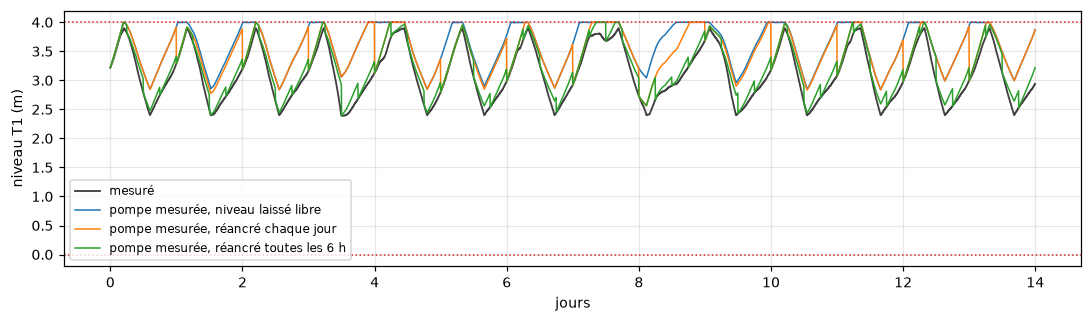

In [13]:
fig, ax = plt.subplots(figsize=(10, 3.0))
j = np.arange(len(libre)) / R.PAS_JOUR
ax.plot(j, niveau[DEBUT:DEBUT + len(libre)], lw=1.2, color="0.25", label="mesuré")
ax.plot(j, libre, lw=1.0, label="pompe mesurée, niveau laissé libre")
ax.plot(j, ancre, lw=1.0, label="pompe mesurée, réancré chaque jour")
ax.plot(j, serre, lw=1.0, label="pompe mesurée, réancré toutes les 6 h")
ax.axhline(4.0, color="C3", ls=":", lw=1); ax.axhline(0.0, color="C3", ls=":", lw=1)
ax.set_xlabel("jours"); ax.set_ylabel("niveau T1 (m)"); ax.legend(fontsize=8)
fig.tight_layout()

In [14]:
vrai = niveau[DEBUT:DEBUT + len(libre)]
sature = lambda h: np.mean((h <= 0.001) | (h >= 3.999))
ecart = lambda h: np.abs(h - vrai[:len(h)]).mean()
print(f"mesuré                     : de {vrai.min():.2f} à {vrai.max():.2f} m")
for nom, h in [("sans ancrage", libre), ("réancré chaque jour", ancre),
               ("réancré toutes les 6 h", serre)]:
    print(f"{nom:27s}: de {h.min():.2f} à {h.max():.2f} m, saturé sur {sature(h):3.0%} des pas, "
          f"écart moyen au capteur {ecart(h):.2f} m")

mesuré                     : de 2.39 à 3.90 m
sans ancrage               : de 2.84 à 4.00 m, saturé sur 20% des pas, écart moyen au capteur 0.49 m
réancré chaque jour        : de 2.56 à 4.00 m, saturé sur  9% des pas, écart moyen au capteur 0.37 m
réancré toutes les 6 h     : de 2.39 à 4.00 m, saturé sur  2% des pas, écart moyen au capteur 0.11 m


### Lecture

Sans ancrage, le niveau part et vient **buter contre le trop-plein**, où il reste collé une bonne
partie du temps. Un réservoir saturé ne joue plus son rôle : il absorbe ou fournit ce qu'on veut
sans que son niveau bouge, et la zone qu'il alimente devient fausse.

La dérive est proportionnelle à l'erreur de demande accumulée, donc plus forte en été, quand la
consommation est la plus mal connue.

L'ancrage — repartir, à chaque tranche, du niveau **lu au capteur** — coûte une ligne. Son
efficacité se règle d'un seul paramètre : plus les tranches sont courtes, moins l'erreur a le
temps de s'accumuler, et le prix est uniquement du temps de calcul.

Il ne supprime pas la saturation, il la borne. **Les deux leviers sont indissociables** : le
premier sans le second ne tient pas.

## 3. Ce que valent les deux leviers, et comment ils se composent

Il est tentant de tester un changement à la fois. Voyons ce que ça donne : croisons le modèle de
demande et les conditions aux limites, sur deux saisons.

In [15]:
def croiser(debut, n=3 * R.PAS_JOUR):
    mes = R.charger_pressions(ANNEE).to_numpy()[debut:debut + n]
    D_nom, _ = P.demandes_nominales(wn, horo[debut:debut + n + 1])
    bc = {"contrôles du fichier": {},
          "pompe mesurée + ancrage": dict(pompe=statut_mesure[debut:debut + n + 1],
                                          niveau_mesure=niveau[debut:debut + n + 1])}
    dem = {"modèle livré": D_nom, "modèle de demande": D_calibre[debut:debut + n + 1]}
    lignes = {}
    for nd, D in dem.items():
        for nb, kw in bc.items():
            S = R.pressions_simulees(D, noeuds, n, tranche_jours=1,
                                     niveau0=float(niveau[debut]), verbeux=False, **kw)
            lignes[(nd, nb)] = G.resume(S, mes)
    return pd.DataFrame(lignes).T

In [16]:
croise = pd.concat({"janvier": croiser(3 * R.PAS_JOUR), "juillet": croiser(DEBUT)})
print(croise[["biais_m", "dispersion_m", "rmse_m"]].round(4).to_string())

                                                   biais_m  dispersion_m  rmse_m
janvier modèle livré      contrôles du fichier     -0.1428        0.2162  0.2591
                          pompe mesurée + ancrage  -0.1141        0.1623  0.1984
        modèle de demande contrôles du fichier      0.0536        0.1229  0.1341
                          pompe mesurée + ancrage   0.0486        0.0697  0.0849
juillet modèle livré      contrôles du fichier      0.3320        0.3090  0.4535
                          pompe mesurée + ancrage   0.3014        0.2285  0.3782
        modèle de demande contrôles du fichier      0.2050        0.2289  0.3072
                          pompe mesurée + ancrage   0.1847        0.1802  0.2580


### Lecture

Regardez la colonne `dispersion_m`, celle qui porte la dynamique. Les deux leviers gagnent
séparément, et ils gagnent surtout **ensemble**.

Ce qui mérite d'être relevé, c'est **comment** les gains se composent.

En juillet, ils se multiplient presque exactement : chacun retire environ un quart de la
dispersion, et le couple un peu plus de quarante pour cent. En janvier, le couple fait nettement
mieux que cette composition.

Autrement dit, **corriger la pompe ne fait pas que retirer sa propre erreur : cela rend le modèle
de demande plus rentable qu'il ne l'était.** Tant que la pompe bascule au mauvais moment, elle
injecte dans le résidu un écart qui recouvre partiellement ce que le modèle de demande
apporterait.

**La leçon de méthode vaut au-delà de ce réseau.** Mesurer les améliorations une par une, dans un
modèle où un autre facteur est encore mal spécifié, **sous-estime leur valeur commune**. Un
tableau croisé coûte quatre simulations au lieu de deux, et il évite d'écarter un raffinement au
vu d'un gain isolé décevant.

À noter aussi, et cela resservira : le plus gros levier unique de ce tableau n'est pas le modèle
de consommation, c'est **une condition aux limites lue dans un capteur déjà installé**.

## 4. La section du réservoir : mesurable en principe, pas en pratique

Le diamètre inscrit dans le modèle est un nombre rond — 16,00 m — c'est-à-dire une valeur de
catalogue plutôt qu'une mesure. Or il devrait se retrouver dans les données sans jamais inverser
le modèle hydraulique : sur tout intervalle où la pompe ne change pas d'état, le réservoir n'a
qu'une entrée (mesurée) et qu'une sortie.

$$ A \cdot \Delta h = \int (Q_{\text{pompe}} - Q_{\text{zone C}})\,dt $$

Chaque demi-cycle de pompe fournit un point, et il y en a plusieurs centaines dans l'année.

In [17]:
sec = A.section_par_demi_cycles(wn, ANNEE)
cycles = sec["demi_cycles"]

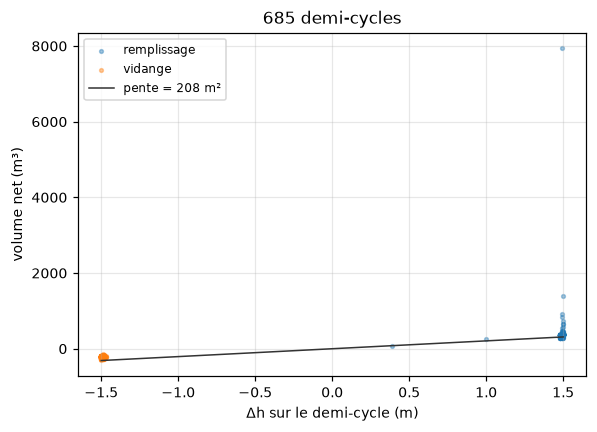

In [18]:
fig, ax = plt.subplots(figsize=(5.5, 4.0))
for p, lib, c in [(1, "remplissage", "C0"), (0, "vidange", "C1")]:
    s = cycles[cycles.pompe == p]
    ax.scatter(s.dh, s.V_net, s=6, alpha=0.4, color=c, label=lib)
x = np.linspace(cycles.dh.min(), cycles.dh.max(), 10)
ax.plot(x, sec["section_m2"] * x, color="0.2", lw=1, label=f"pente = {sec['section_m2']:.0f} m²")
ax.set_xlabel("Δh sur le demi-cycle (m)"); ax.set_ylabel("volume net (m³)")
ax.legend(fontsize=8); ax.set_title(f"{sec['n_demi_cycles']} demi-cycles")
fig.tight_layout()

In [19]:
print(f"section du modèle           : {sec['section_du_modele_m2']:.1f} m²  "
      f"(diamètre {sec['diametre_du_modele_m']:.2f} m)")
print(f"estimée, erreur sur volumes : {sec['encadrement_m2'][0]:.1f} m²  "
      f"(diamètre {sec['encadrement_diametre_m'][0]:.2f} m)")
print(f"estimée, erreur sur niveaux : {sec['encadrement_m2'][1]:.1f} m²  "
      f"(diamètre {sec['encadrement_diametre_m'][1]:.2f} m)")

section du modèle           : 201.1 m²  (diamètre 16.00 m)
estimée, erreur sur volumes : 207.9 m²  (diamètre 16.27 m)
estimée, erreur sur niveaux : 414.0 m²  (diamètre 22.96 m)


Le nuage est convaincant, et pourtant les deux estimateurs sont **incompatibles** : selon le sens
dans lequel on ajuste la droite, la section varie du simple au double. Chacun pris seul aurait
donné une barre d'erreur étroite et rassurante.

L'explication tient en un nombre.

In [20]:
print(f"corrélation entre volume pompé et volume consommé, sur un remplissage : "
      f"{sec['correlation_remplissage']:.3f}")
print(f"si l'on laisse la consommation de la zone C libre d'un facteur d'échelle :")
print(f"   section {sec['section_echelle_libre_m2']:.1f} m², "
      f"facteur sur la consommation ×{sec['echelle_zoneC']:.2f}")

corrélation entre volume pompé et volume consommé, sur un remplissage : 0.997
si l'on laisse la consommation de la zone C libre d'un facteur d'échelle :
   section 228.4 m², facteur sur la consommation ×1.72


Voilà la cause. Sur un demi-cycle de **remplissage**, le volume pompé et le volume consommé sont
tous deux proportionnels à la durée du cycle : ils sont colinéaires à **0,997**.

Deux régresseurs colinéaires ne se séparent pas, quelle que soit la quantité de données. La
droite mesure en réalité une **combinaison** de la section et de la consommation de la zone — et
laisser cette dernière libre absorbe l'écart sans difficulté.

### Contourner l'aliasing plutôt que le subir

Le découpage en demi-cycles jette une information, et c'est précisément celle qui manque. Les
deux régimes ne sont **pas symétriques** :

* pompe à l'arrêt, la pente du niveau vaut $-Q_C/A$ — elle ne donne qu'un rapport ;
* pompe en marche, elle vaut $(Q_p - Q_C)/A$, et le débit de la pompe, lui, est **mesuré**.

Les deux régimes ensemble séparent donc $A$ de $Q_C$. Encore faut-il les faire travailler
ensemble : plutôt qu'une droite sur des demi-cycles indépendants, on simule la trajectoire
**complète** du niveau — sans jamais la réancrer, puisque c'est l'accumulation libre de l'écart
qui porte l'information — et on balaye les deux paramètres.

In [21]:
# Fenêtre de janvier, et non de juillet : voir juste après pourquoi le choix n'est pas anodin.
grille = A.ajuster_reservoir(D_calibre, noeuds, wn, ANNEE,
                             debut=3 * R.PAS_JOUR, n_pas=14 * R.PAS_JOUR,
                             diametres=(14.0, 15.0, 16.0, 17.0),
                             echelles=(1.0, 1.4, 1.8), verbeux=False)
print(grille.to_string(index=False))

 diametre_m  echelle_zoneC  erreur_niveau_m   sature
       16.0            1.0         0.201988 0.005456
       17.0            1.0         0.213216 0.003472
       15.0            1.0         0.213927 0.006944
       14.0            1.0         0.264053 0.008681
       17.0            1.4         2.729589 0.497520
       16.0            1.4         2.749993 0.508681
       15.0            1.4         2.753918 0.519841
       14.0            1.4         2.759127 0.529514
       14.0            1.8         2.925301 0.639385
       17.0            1.8         2.926201 0.619048
       15.0            1.8         2.926254 0.634177
       16.0            1.8         2.926594 0.627232


Le facteur d'échelle sur la consommation de la zone C se fixe **sans ambiguïté à 1** : dès 1,4,
l'erreur de niveau est treize fois pire et le réservoir sature la moitié du temps.

Le ×1,72 que la régression proposait était donc bien un artefact de colinéarité, et non une
consommation cachée. **L'aliasing est levé** — parce qu'on a simulé au lieu de régresser, pas
parce qu'on a ajouté des données.

Le diamètre, lui, a bien un minimum **intérieur**, et sur cette grille il tombe sur 16 m, la
valeur même du fichier. Mais le critère est plat : trois mètres de diamètre ne déplacent l'erreur
que d'une dizaine de pour cent. C'est une confirmation, pas une mesure de précision.

### La condition à vérifier, et ce qui arrive quand on l'oublie

Cette fenêtre a été choisie en janvier pour une raison. Reprenons le même balayage à deux autres
saisons.

In [22]:
for lib, deb in [("juillet", DEBUT), ("octobre", 275 * R.PAS_JOUR)]:
    t = A.ajuster_reservoir(D_calibre, noeuds, wn, ANNEE, debut=deb, n_pas=14 * R.PAS_JOUR,
                            diametres=(14.0, 15.0, 16.0, 17.0), echelles=(1.0,), verbeux=False)
    t = t.sort_values("diametre_m")
    detail = "   ".join(f"{r.diametre_m:.0f} m : {r.erreur_niveau_m:.3f} m" for r in t.itertuples())
    print(f"{lib:8s} {detail}   | saturé {t.sature.mean():.0%} du temps")

juillet  14 m : 0.457 m   15 m : 0.504 m   16 m : 0.551 m   17 m : 0.592 m   | saturé 20% du temps


octobre  14 m : 0.419 m   15 m : 0.473 m   16 m : 0.521 m   17 m : 0.563 m   | saturé 14% du temps


### Lecture

En juillet et en octobre, l'erreur **décroît sans minimum** jusqu'au bord de la grille : le
balayage réclame le plus petit réservoir qu'on lui propose.

Ce n'est pas une mesure, c'est un artefact, et la colonne `sature` le dénonce — le réservoir
passe 13 à 20 % du temps collé au trop-plein. Or un réservoir plus petit se remplit et se vide
plus vite, donc y passe moins de temps : **l'optimiseur poursuit la saturation, pas la physique.**

**La leçon vaut au-delà du réservoir.** Le critère ne prévient pas qu'il est devenu vide de sens ;
il continue de produire un minimum, et ce minimum est au bord.

Un paramètre estimé par optimisation demande donc deux vérifications distinctes : que l'optimum
soit **intérieur**, et que le régime simulé soit **celui qu'on croit**. C'est pour cela que
`ajuster_reservoir` renvoie la saturation à côté de l'erreur, plutôt que le seul meilleur point.

### Et pour finir : est-ce que cela change quelque chose ?

Puisque le levier 2 réancre le niveau sur son capteur à chaque tranche, la section ne gouverne
plus que la dynamique **à l'intérieur** d'une tranche.

In [23]:
bc = dict(pompe=statut_mesure[DEBUT:DEBUT + N_PAS + 1], niveau_mesure=niveau[DEBUT:DEBUT + N_PAS + 1])
faire = lambda D, **kw: R.pressions_simulees(D, noeuds, N_PAS, tranche_jours=1,
                                             niveau0=float(niveau[DEBUT]), verbeux=False, **kw)

In [24]:
S_bc = faire(D_calibre[DEBUT:DEBUT + N_PAS + 1], **bc)
S_sec = faire(D_calibre[DEBUT:DEBUT + N_PAS + 1], **bc,
              diametre_T1=sec["encadrement_diametre_m"][0])

print(G.tableau({"section du modèle": S_bc, "section estimée": S_sec}, mesure).round(4).to_string())

                   biais_m  dispersion_m  rmse_m   max_m   n_pas  gain_dispersion  gain_rmse
section du modèle   0.1832        0.1888  0.2631  1.6383  2016.0           0.0000     0.0000
section estimée     0.1834        0.1903  0.2643  1.6672  2016.0           0.0083     0.0047


Rien. Et sur l'année entière, même conclusion : 0,1992 m de RMSE avec la section du fichier,
0,2000 m avec la section estimée.

Le levier 3 est donc **à écarter, mais pas pour la raison qu'on croyait**. La section n'est pas
« non identifiable » : elle l'est, pourvu qu'on simule au lieu de régresser et qu'on choisisse une
fenêtre où le réservoir respire. Elle est simplement **sans effet** une fois le niveau réancré —
le levier 2 a déjà pris ce qu'elle aurait apporté.

## 5. Le niveau de la demande est mesuré, pas à modéliser

Dernier levier. La consommation totale de la grande zone n'a pas besoin d'être modélisée : elle
se lit par différence entre les débitmètres d'entrée et celui de la pompe.

Le modèle de demande garde la répartition entre nœuds et la forme temporelle ; on ne lui impose
que le niveau d'ensemble, par blocs d'une semaine.

In [25]:
D_recale = A.recaler_zone_ab(D_calibre, noeuds, wn, ANNEE, periode=R.PAS_SEMAINE)
S_bilan = faire(D_recale[DEBUT:DEBUT + N_PAS + 1], **bc)

print(G.tableau({"modèle de demande": S_bc, "+ bilan de masse": S_bilan}, mesure).round(4).to_string())

                   biais_m  dispersion_m  rmse_m   max_m   n_pas  gain_dispersion  gain_rmse
modèle de demande   0.1832        0.1888  0.2631  1.6383  2016.0           0.0000     0.0000
+ bilan de masse    0.1515        0.1882  0.2417  1.6383  2016.0          -0.0027    -0.0814


Le biais tombe, la dispersion ne bouge pas. C'est exactement ce qu'on doit attendre : un niveau
de demande trop bas déplace toutes les pressions dans le même sens, donc produit un **décalage**,
et corriger un décalage ne change rien à la dynamique.

⚠️ **Une réserve importante.** Le débit d'entrée contient tout ce qui sort du réseau, y compris ce
qui fuit. Recaler la demande sur le bilan de masse **absorbe donc les fuites dans la demande**.

C'est sans conséquence pour calibrer un modèle hydraulique, et c'est rédhibitoire si l'on compte
ensuite chercher des fuites dans le résidu : dans ce cas, il faut ajuster le recalage sur une
période saine et le transporter, sans jamais le laisser suivre la mesure en continu.

## 6. Retour sur les rugosités

Le premier carnet a ajusté six coefficients pour un gain modeste, et a renvoyé l'explication ici.
Reprenons la question dans les bonnes conditions aux limites.

D'abord, sur quelle fenêtre régler ? Le jeu de données publie les fuites qu'il contient, ce qui
permet de répondre par la mesure.

In [26]:
# Ce que chaque fenêtre porte comme fuite. Le jeu de données le publie : on ne s'en sert pas
# pour calibrer, seulement pour savoir sur quoi on a réglé.
FEN = {"janvier": 3 * R.PAS_JOUR, "juillet": DEBUT, "octobre": 275 * R.PAS_JOUR}

lignes = {"semaine 1 (protocole publié)": R.charge_de_fuite(ANNEE, 0, R.PAS_SEMAINE)}
for nom, d in FEN.items():
    lignes[nom] = R.charge_de_fuite(ANNEE, d, N_PAS)
print(pd.DataFrame(lignes).T.rename(columns={
    "debit_m3h": "fuite (m³/h)", "fuites_vives": "fuites vives",
    "part_conso_ab": "part de la conso A+B"}).round(3).to_string())

                              fuite (m³/h)  fuites vives  part de la conso A+B
semaine 1 (protocole publié)         0.000         0.000                 0.000
janvier                              0.017         0.236                 0.000
juillet                             12.282         3.000                 0.070
octobre                             34.322         4.556                 0.196


C'est pourquoi l'ajustement qui suit se fait sur la **semaine 1**, comme la référence, et non sur
la fenêtre d'évaluation.

Le raisonnement de départ est le suivant. Régler en juillet, ce serait régler sur une fenêtre
portant **12 m³/h de fuite**, puis évaluer sur des fenêtres qui n'en portent aucune, ou trois
fois plus. Or une fuite ressemble hydrauliquement à de la friction : les deux font **baisser la
pression en aval**. Un optimiseur qui n'a que la rugosité sous la main devrait donc payer la
fuite avec de la rugosité.

C'est une hypothèse, pas un résultat. Le §7 la met à l'épreuve — et la contredit en partie.

Commençons par le contrôle le plus simple : **un seul** facteur, appliqué à tout le réseau,
balayé.

In [27]:
groupes = R.groupes_de_rugosite(wn, n_groupes=6)
noms_groupes = sorted(set(groupes.values()))
depart = U.coefficients_initiaux(wn, groupes)
mesure_entr = R.charger_pressions(ANNEE).to_numpy()[DEBUT_ENTR:DEBUT_ENTR + N_ENTR]

In [28]:
import inspect
sig = inspect.signature(U.ajuster).parameters
print(f"bornes sur le coefficient : {sig['bornes'].default}, "
      f"seuil de Huber : {sig['huber'].default}")
print("coefficients de départ :", {k: round(v, 1) for k, v in depart.items()})

bornes sur le coefficient : (60.0, 160.0), seuil de Huber : 1.345
coefficients de départ : {'D100': 137.1, 'D150': 137.7, 'D160': 140.0, 'D200': 140.0, 'D225': 140.0, 'D<=75': 135.3}


In [29]:
bc_entr = dict(pompe=statut_mesure[DEBUT_ENTR:DEBUT_ENTR + N_ENTR + 1],
               niveau_mesure=niveau[DEBUT_ENTR:DEBUT_ENTR + N_ENTR + 1])

def simulateur(coefficients):
    return R.pressions_simulees(D_recale[DEBUT_ENTR:DEBUT_ENTR + N_ENTR + 1], noeuds, N_ENTR,
                                tranche_jours=1, niveau0=float(niveau[DEBUT_ENTR]), verbeux=False,
                                coefficients=U.coefficients_par_conduite(groupes, coefficients),
                                **bc_entr)

In [30]:
bal = U.balayage(simulateur, mesure_entr, depart,
                 valeurs=(0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15), verbeux=False)
print(bal.round(4).to_string(index=False))

 facteur   rmse   biais  dispersion
    0.85 0.1692 -0.1034      0.1339
    0.90 0.1066 -0.0333      0.1013
    0.95 0.0901  0.0266      0.0860
    1.00 0.1174  0.0782      0.0876
    1.05 0.1583  0.1229      0.0998
    1.10 0.1994  0.1620      0.1162
    1.15 0.2374  0.1963      0.1335


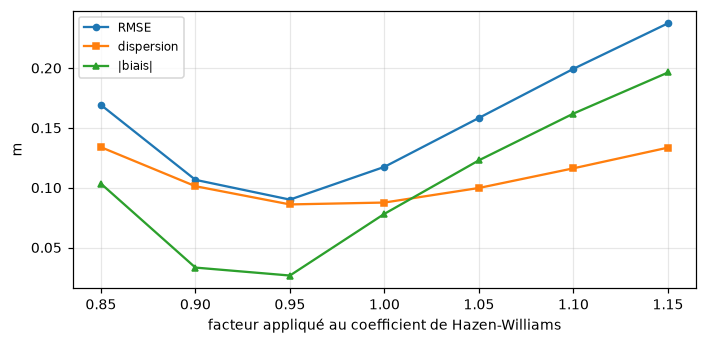

In [31]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(bal.facteur, bal.rmse, marker="o", ms=4, label="RMSE")
ax.plot(bal.facteur, bal.dispersion, marker="s", ms=4, label="dispersion")
ax.plot(bal.facteur, np.abs(bal.biais), marker="^", ms=4, label="|biais|")
ax.set_xlabel("facteur appliqué au coefficient de Hazen-Williams"); ax.set_ylabel("m")
ax.legend(fontsize=8)
fig.tight_layout()

### Lecture

Voilà la figure qui résume le problème. La RMSE a bien un minimum net, et ce minimum tombe
exactement **là où le biais change de signe**. La dispersion, elle, bouge à peine sur toute la
plage, et son propre minimum n'est pas au même endroit : au facteur qui optimise la RMSE, la
dispersion est *moins bonne* qu'à facteur 1.

Autrement dit, ajuster la rugosité ne fait pas mieux coller le modèle au réseau : cela déplace
toutes les pressions **en bloc** jusqu'à compenser une erreur de niveau qui n'a rien à voir avec
la friction.

C'est un paramètre physique utilisé comme une constante d'étalonnage. Cela améliore une métrique
sans améliorer le modèle — et l'on ne peut le voir qu'en séparant le biais de la dispersion.

Pourquoi si peu de prise ? Il suffit de regarder ce que les conduites perdent réellement.

In [32]:
pertes = U.pertes_de_charge(D_recale[DEBUT:DEBUT + R.PAS_JOUR + 1], noeuds, R.PAS_JOUR,
                            tranche_jours=1, niveau0=float(niveau[DEBUT]), verbeux=False,
                            pompe=statut_mesure[DEBUT:DEBUT + R.PAS_JOUR + 1],
                            niveau_mesure=niveau[DEBUT:DEBUT + R.PAS_JOUR + 1])

In [33]:
print(f"perte de charge médiane d'une conduite : {pertes.mediane_m.median() * 1000:.2f} mm")
print(f"9 conduites sur 10 sont sous            : {pertes.mediane_m.quantile(0.9) * 1000:.2f} mm")
print(f"perte maximale observée                 : {pertes.maximum_m.max() * 1000:.0f} mm")

perte de charge médiane d'une conduite : 4.11 mm
9 conduites sur 10 sont sous            : 44.37 mm
perte maximale observée                 : 456 mm


In [34]:
print("part de la friction totale portée par les conduites les plus chargées :")
print(U.concentration(pertes).round(3).to_string())

part de la friction totale portée par les conduites les plus chargées :
1 % des conduites     0.129
5 % des conduites     0.378
10 % des conduites    0.564
25 % des conduites    0.820
50 % des conduites    0.950


In [35]:
print("les dix conduites les plus chargées :")
print(pertes.head(10).round({"mediane_m": 4, "maximum_m": 4}).to_string())

les dix conduites les plus chargées :
      mediane_m  maximum_m  longueur_m  diametre_mm
p110     0.3515     0.4559     69.0704        200.0
p105     0.2639     0.3307     50.1743        100.0
p235     0.1886     0.2421     36.1780        200.0
p479     0.1795     0.2389     44.8971        100.0
p480     0.1712     0.2295     44.8925        100.0
p228     0.1447     0.2044     46.7558        150.0
p189     0.1418     0.1779     55.1111        100.0
p220     0.1268     0.1594     69.6172        100.0
p227     0.1268     0.1605     26.9092        200.0
p839     0.1249     0.1544     56.3034        100.0


**Le réseau est presque sans friction.** La conduite médiane perd quelques millimètres de charge,
si bien que changer son coefficient de 10 % la déplacerait d'une fraction de millimètre — alors
que les capteurs sont arrondis au centimètre et que l'écart à expliquer se compte en dizaines de
centimètres.

**Et la friction qui existe est très concentrée** : un dixième des conduites en porte plus de la
moitié, et les premières du classement sont les conduites d'arrivée et de transport — celles-là
mêmes dont le débit dépend de l'état de la pompe.

Les centaines de conduites restantes ne portent donc aucune information exploitable. Les
regrouper en six familles plutôt qu'en une seule ajoute cinq paramètres qui n'ont presque rien à
identifier — et un paramètre sans information ne reste pas inerte, il se met au service de
l'erreur qui domine la fenêtre d'ajustement.

In [36]:
# chaque colonne du jacobien coûte une simulation de plus : le nombre d'évaluations réelles
# est bien supérieur à `max_nfev`, qui ne compte que les évaluations principales
ajustement = U.ajuster(simulateur, mesure_entr, depart, max_nfev=12, verbeux=False)
print(f"{ajustement['n_evaluations']} simulations en {ajustement['secondes']:.0f} s ; "
      f"RMSE d'ajustement {ajustement['rmse_depart']:.4f} → {ajustement['rmse']:.4f} m")
print(pd.Series(ajustement["coefficients"]).round(1).to_string())
print(f"\ndépart : {pd.Series(ajustement['depart']).round(1).to_dict()}")
print(f"groupes arrêtés sur une borne : {ajustement['aux_bornes'] or 'aucun'}")

67 simulations en 75 s ; RMSE d'ajustement 0.1174 → 0.0734 m
D100      82.4
D150     160.0
D160     160.0
D200     146.0
D225     160.0
D<=75    160.0

départ : {'D100': 137.1, 'D150': 137.7, 'D160': 140.0, 'D200': 140.0, 'D225': 140.0, 'D<=75': 135.3}
groupes arrêtés sur une borne : ['D160']


Vérifions-le. Un seul test tranche vraiment pour une calibration — **est-ce que ça transfère ?**
Jugeons les deux jeux de facteurs sur la fenêtre qui a servi à les régler, puis sur deux périodes
de l'année qui n'ont servi à rien.

In [37]:
meilleur = float(bal.loc[bal.rmse.idxmin(), "facteur"])
jeux = {"sans ajustement": None,
        f"un facteur global ×{meilleur:g}": {g: c * meilleur for g, c in depart.items()},
        "six coefficients ajustés": ajustement["coefficients"]}

In [38]:
def sur_fenetre(debut, n=N_PAS):
    mes = R.charger_pressions(ANNEE).to_numpy()[debut:debut + n]
    kw = dict(pompe=statut_mesure[debut:debut + n + 1], niveau_mesure=niveau[debut:debut + n + 1])
    sorties = {}
    for nom, rg in jeux.items():
        sorties[nom] = R.pressions_simulees(
            D_recale[debut:debut + n + 1], noeuds, n, tranche_jours=1,
            niveau0=float(niveau[debut]), verbeux=False,
            coefficients=None if rg is None else U.coefficients_par_conduite(groupes, rg),
            **kw)
    return G.tableau(sorties, mes)

In [39]:
transfert = pd.concat({"semaine 1 (fenêtre d'ajustement)": sur_fenetre(DEBUT_ENTR),
                       "juillet (jamais vu)": sur_fenetre(DEBUT),
                       "octobre (jamais vu)": sur_fenetre(275 * R.PAS_JOUR)})
print(transfert[["biais_m", "dispersion_m", "rmse_m", "gain_dispersion"]].round(4).to_string())

                                                           biais_m  dispersion_m  rmse_m  gain_dispersion
semaine 1 (fenêtre d'ajustement) sans ajustement            0.0617        0.0833  0.1037           0.0000
                                 un facteur global ×0.95    0.0085        0.0743  0.0747          -0.1086
                                 six coefficients ajustés  -0.0067        0.0807  0.0810          -0.0314
juillet (jamais vu)              sans ajustement            0.1515        0.1882  0.2417           0.0000
                                 un facteur global ×0.95    0.0589        0.1936  0.2023           0.0283
                                 six coefficients ajustés   0.0320        0.1622  0.1654          -0.1381
octobre (jamais vu)              sans ajustement            0.1805        0.2141  0.2800           0.0000
                                 un facteur global ×0.95    0.0797        0.2281  0.2417           0.0656
                                 six coefficie

Le tableau se lit en oubliant la colonne RMSE.

Les deux jeux retirent surtout du **biais** : +0,15 m → +0,03 m en juillet, +0,18 → +0,06 en
octobre. C'est un recentrage, pas une calibration.

Sur la **dispersion**, le facteur global fait ce que le balayage annonçait : il aide sa propre
fenêtre (−11 %) et dégrade les deux autres (+3 %, +7 %). Les six coefficients, eux, améliorent
les trois (−3 %, −14 %, −4 %).

On serait tenté d'en conclure que la calibration a marché. Le paragraphe suivant montre que non.

## 7. Est-ce que ces six coefficients veulent dire quelque chose ?

Un coefficient de rugosité est censé décrire une conduite, pas une semaine. Le test est donc
simple : refaire **exactement le même ajustement** sur trois fenêtres différentes. Deux ne
portent aucune fuite — la semaine 1, et janvier trois jours plus tard ; la troisième porte les
12 m³/h de juillet.

**Si les coefficients mesurent la friction des conduites, les deux fenêtres propres doivent
donner la même réponse.**

In [40]:
pres = R.charger_pressions(ANNEE).to_numpy()
FEN = {"semaine 1": DEBUT_ENTR, "juillet": DEBUT, "octobre": 275 * R.PAS_JOUR}

def simuler_fenetre(debut, n, coefs=None):
    return R.pressions_simulees(
        D_recale[debut:debut + n + 1], noeuds, n, tranche_jours=1,
        niveau0=float(niveau[debut]), verbeux=False,
        pompe=statut_mesure[debut:debut + n + 1], niveau_mesure=niveau[debut:debut + n + 1],
        coefficients=None if coefs is None else U.coefficients_par_conduite(groupes, coefs))

def ajuster_sur(debut, **kw):
    return U.ajuster(lambda c: simuler_fenetre(debut, N_ENTR, c), pres[debut:debut + N_ENTR],
                     depart, max_nfev=12, verbeux=False, **kw)

reference = {nom: G.resume(simuler_fenetre(d, N_PAS), pres[d:d + N_PAS])["dispersion_m"]
             for nom, d in FEN.items()}

In [41]:
def transfert(coefs):
    """Variation de dispersion, en %, sur les trois fenêtres."""
    sortie = {}
    for nom, d in FEN.items():
        obtenu = G.resume(simuler_fenetre(d, N_PAS, coefs), pres[d:d + N_PAS])["dispersion_m"]
        sortie[nom] = 100 * (obtenu / reference[nom] - 1)
    return sortie

In [42]:
sur_juillet = ajuster_sur(DEBUT)
sur_janvier = ajuster_sur(3 * R.PAS_JOUR)        # trois jours plus tard, sans fuite elle aussi
essais = {"semaine 1 (jours 1-2, sans fuite)": ajustement["coefficients"],
          "janvier (jours 4-5, sans fuite)": sur_janvier["coefficients"],
          "juillet (12 m³/h de fuite)": sur_juillet["coefficients"]}

In [43]:
print("coefficients obtenus :")
print(pd.DataFrame({"départ (fichier)": depart, **essais}).round(0).to_string())
for nom, sol in [("semaine 1", ajustement), ("janvier", sur_janvier), ("juillet", sur_juillet)]:
    print(f"  {nom:10s} groupes sur une borne : {sol['aux_bornes'] or 'aucun'}")
print("\nvariation de dispersion (%), les trois fenêtres :")
print(pd.DataFrame({k: transfert(v) for k, v in essais.items()}).round(1).to_string())

coefficients obtenus :
       départ (fichier)  semaine 1 (jours 1-2, sans fuite)  janvier (jours 4-5, sans fuite)  juillet (12 m³/h de fuite)
D100              137.0                               82.0                            137.0                        72.0
D150              138.0                              160.0                            137.0                       160.0
D160              140.0                              160.0                             75.0                       160.0
D200              140.0                              146.0                            128.0                       150.0
D225              140.0                              160.0                             76.0                       160.0
D<=75             135.0                              160.0                            109.0                       160.0
  semaine 1  groupes sur une borne : ['D160']
  janvier    groupes sur une borne : aucun
  juillet    groupes sur une borne : ['D150', 'D

           semaine 1 (jours 1-2, sans fuite)  janvier (jours 4-5, sans fuite)  juillet (12 m³/h de fuite)
semaine 1                               -3.1                            -10.6                        10.0
juillet                                -13.8                              4.6                       -13.2
octobre                                 -4.1                              8.7                        -3.0


Elles ne la donnent pas.

D100 couvre 705 conduites sur 905. La semaine 1 le fait tomber à 82, janvier le laisse à 137,
juillet le fait tomber à 72. Sur D160, seize conduites : 160 d'un côté, 75 de l'autre — les deux
extrémités de l'intervalle autorisé, sur les mêmes conduites, à trois jours d'écart.

**Un paramètre qui change autant selon la fenêtre n'est pas mesuré.**

Et l'écart ne sépare pas les fenêtres propres de la fenêtre fuyarde : la semaine 1 répond comme
juillet, c'est janvier qui est à part. Ce n'est donc pas la fuite qui pilote le résultat —
l'hypothèse du §6 ne tient pas telle quelle.

Le tableau de transfert raconte la même chose. Chaque réglage aide les fenêtres qui ressemblent à
la sienne et dégrade les autres : janvier gagne 11 % sur la semaine 1 mais perd 5 % en juillet et
9 % en octobre ; juillet fait l'inverse, +10 % sur la semaine 1.

Que la semaine 1 améliore les trois à la fois est une coïncidence heureuse, pas une propriété.

Reste une question : d'où vient ce −13 % que deux fenêtres sur trois trouvent en juillet ? Une
façon de le savoir est d'interdire au modèle de trop s'éloigner des valeurs du fichier.

In [44]:
# Deux façons de dire « la vérité est près de la valeur du fichier » :
# une contrainte dure (bornes) ou une pénalité molle (Tikhonov).
bornes = U.bornes_par_groupe(wn, groupes, marge=0.10)
print("bornes par groupe, à ±10 % des coefficients que le groupe porte déjà :")
print(pd.DataFrame(bornes, index=["bas", "haut"]).T.to_string())
print(f"\npour mémoire, le fichier ne contient que deux valeurs : "
      f"{pd.Series({p: wn.get_link(p).roughness for p in wn.pipe_name_list}).value_counts().to_dict()}")
print(f"l'encadrement publié (60, 160) autorise donc "
      f"{60 / depart['D100'] - 1:+.0%} à {160 / depart['D100'] - 1:+.0%} autour du départ\n")

bornes par groupe, à ±10 % des coefficients que le groupe porte déjà :
         bas   haut
D100   108.0  154.0
D150   108.0  154.0
D160   126.0  154.0
D200   126.0  154.0
D225   126.0  154.0
D<=75  108.0  154.0

pour mémoire, le fichier ne contient que deux valeurs : {140.0: 786, 120.0: 119}
l'encadrement publié (60, 160) autorise donc -56% à +17% autour du départ



In [45]:
variantes = {"juillet, tel quel (60–160, α = 0)": sur_juillet["coefficients"],
             "juillet + bornes à ±10 %": ajuster_sur(DEBUT, bornes=bornes)["coefficients"],
             "semaine 1 + bornes à ±10 %": ajuster_sur(DEBUT_ENTR, bornes=bornes)["coefficients"],
             "juillet + régularisation α = 0,01": ajuster_sur(DEBUT, tikhonov=0.01)["coefficients"],
             "juillet + régularisation α = 0,1": ajuster_sur(DEBUT, tikhonov=0.1)["coefficients"]}

In [46]:
print(pd.DataFrame({"départ": depart, "semaine 1 (le défaut)": ajustement["coefficients"],
                    **variantes}).round(0).to_string())
print("\nvariation de dispersion (%) :")
print(pd.DataFrame({"semaine 1 (le défaut)": transfert(ajustement["coefficients"]),
                    **{k: transfert(v) for k, v in variantes.items()}}).round(1).to_string())

       départ  semaine 1 (le défaut)  juillet, tel quel (60–160, α = 0)  juillet + bornes à ±10 %  semaine 1 + bornes à ±10 %  juillet + régularisation α = 0,01  juillet + régularisation α = 0,1
D100    137.0                   82.0                               72.0                     108.0                       108.0                              116.0                             132.0
D150    138.0                  160.0                              160.0                     154.0                       154.0                              138.0                             135.0
D160    140.0                  160.0                              160.0                     151.0                       154.0                              140.0                             140.0
D200    140.0                  146.0                              150.0                     129.0                       133.0                              132.0                             132.0
D225    140.0            

           semaine 1 (le défaut)  juillet, tel quel (60–160, α = 0)  juillet + bornes à ±10 %  semaine 1 + bornes à ±10 %  juillet + régularisation α = 0,01  juillet + régularisation α = 0,1
semaine 1                   -3.1                               10.0                     -11.7                       -12.8                              -11.6                             -10.6
juillet                    -13.8                              -13.2                      -0.1                        -3.5                                2.5                               2.0
octobre                     -4.1                               -3.0                       9.0                         4.4                                9.0                               5.7


### Ce que les garde-fous valent vraiment

Il n'en reste presque rien.

Avec les bornes à ±10 %, les deux réglages — la fenêtre propre et la fenêtre fuyarde — tombent
sur **le même vecteur** : D100 à 108, tout le reste collé à 154, c'est-à-dire sur les bornes. Ce
n'est plus la donnée qui décide, c'est la contrainte.

Le −13,2 % de juillet ne survit à aucune contrainte : −0,1 avec les bornes, +2,5 avec α = 0,01.
Mais le −13,8 % que la fenêtre **propre** obtenait sur juillet n'y survit pas davantage (−3,5).

**Les deux gains sont le même artefact.**

**La conclusion est donc négative, et plus large que ce que le §6 annonçait.** Le problème n'est
pas la fuite de juillet, qu'un meilleur choix de fenêtre aurait suffi à régler : c'est qu'il n'y
a pas assez de friction dans ce réseau pour identifier six coefficients, **quelle que soit la
fenêtre**.

Le tableau des pertes de charge le disait déjà en millimètres. Le calcul sur l'année complète,
dans le README, donne le même verdict : sur douze mois, l'ajustement déplace la dispersion de
0,3 %.

> **Corrigé par le carnet 5.** Cette conclusion est trop large, et c'est le regroupement qui en
> est responsable. Le groupe `D100` réunit 104 conduites dont le coefficient vrai vaut 120 et 601
> dont il vaut 140 : un seul paramètre pour deux valeurs, donc un paramètre qui ne peut pas
> converger. En croisant zone × coefficient × diamètre, les quatre groupes qui portent
> 748 conduites sur 905 deviennent stables d'une fenêtre à l'autre — 130, 130, 123 là où `D100`
> donnait 82, 137, 72. Ce qui reste instable se concentre alors sur **sept** conduites : les deux
> entrées du réseau, la sortie du réservoir et la conduite de transport de la zone C.

Cela ne veut pas dire que les deux mécanismes se valent. **Une borne encode un fait** — si l'on
sait que les paramètres du jeu de données ont été écartés d'au plus 10 % de leur valeur vraie,
c'est une contrainte dure, et elle ne se règle pas. **La régularisation encode une préférence**,
et son α est un paramètre libre de plus, qu'il faudrait régler sur une fenêtre.

À noter au passage : l'encadrement publié (60, 160) ne contraint rien ici. Le fichier ne contient
que deux coefficients, 120 et 140, si bien que ces bornes autorisent −56 % à +17 % autour du
départ.

> **Un défaut d'implémentation corrigé au passage.** `least_squares(loss="huber")` applique la
> perte robuste à **tout** le vecteur qu'on lui rend, donc aussi aux lignes de régularisation
> qu'on y aurait concaténées. Au-delà de quelques unités d'écart, la pénalité croissait alors en
> `|x − x₀|` et non en `(x − x₀)²` : ce n'était plus du Tikhonov mais du L1, affaibli précisément
> là où on le voudrait fort. `ajuster` applique désormais Huber à la main sur les seuls résidus
> de mesure et laisse la pénalité quadratique.

## 8. Bilan

Reprenons les leviers dans l'ordre, cumulés, sur la fenêtre d'évaluation.

In [47]:
S_depart = faire(P.demandes_nominales(wn, horo[DEBUT:DEBUT + N_PAS + 1])[0])
S_demande = faire(D_calibre[DEBUT:DEBUT + N_PAS + 1])

final = G.tableau({
    "modèle livré": S_depart,
    "+ modèle de demande": S_demande,
    "+ pompe mesurée et niveau ancré": S_bc,
    "+ bilan de masse": S_bilan,
    "+ rugosité globale": faire(
        D_recale[DEBUT:DEBUT + N_PAS + 1], **bc,
        coefficients=U.coefficients_par_conduite(groupes,
                                                 {g: c * meilleur for g, c in depart.items()})),
}, mesure)
print(final[["biais_m", "dispersion_m", "rmse_m", "gain_dispersion", "gain_rmse"]].round(4).to_string())

                                 biais_m  dispersion_m  rmse_m  gain_dispersion  gain_rmse
modèle livré                      0.3412        0.3290  0.4740           0.0000     0.0000
+ modèle de demande               0.2022        0.2526  0.3235          -0.2324    -0.3174
+ pompe mesurée et niveau ancré   0.1832        0.1888  0.2631          -0.4263    -0.4450
+ bilan de masse                  0.1515        0.1882  0.2417          -0.4279    -0.4902
+ rugosité globale                0.0589        0.1936  0.2023          -0.4117    -0.5731


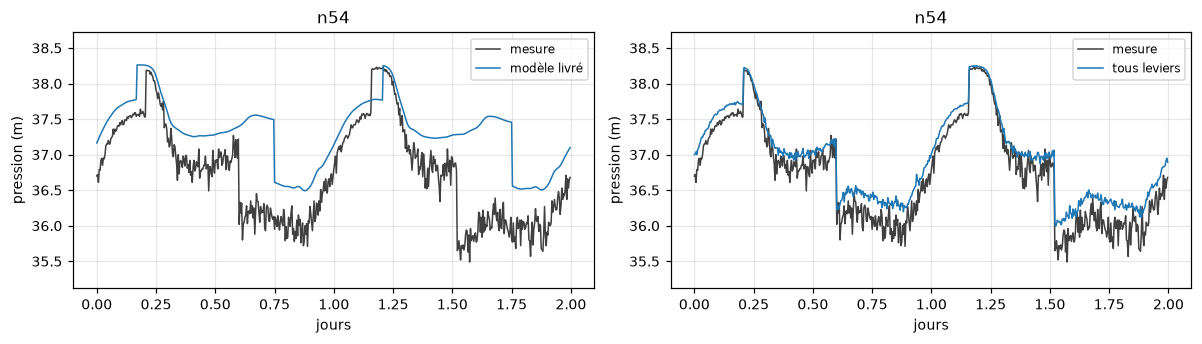

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
G.tracer_capteur(axes[0], S_depart, mesure, "n54", n_pas=2 * R.PAS_JOUR, etiquette="modèle livré")
G.tracer_capteur(axes[1], S_bilan, mesure, "n54", n_pas=2 * R.PAS_JOUR, etiquette="tous leviers")
for ax in axes:
    ax.set_ylim(np.percentile(mesure[:2 * R.PAS_JOUR, R.capteurs()["pressure"].index("n54")],
                              [0.5, 99.5]) + np.array([-0.5, 0.5]))
fig.tight_layout()

### Ce qu'il faut retenir

1. **Une condition aux limites lue dans un capteur vaut un modèle entier.** Prendre l'état de la
   pompe au débitmètre et réancrer le niveau du réservoir sur son capteur tient en deux lignes et
   retire plus de dispersion que toute la décomposition des compteurs.
2. **Les gains se composent, et pas en s'additionnant.** Le modèle de demande rapporte davantage
   une fois la pompe corrigée qu'il ne le laissait voir seul. Mesurer les améliorations une par
   une, dans un modèle où un autre facteur est encore faux, sous-estime leur valeur commune.
3. **Séparer le biais de la dispersion change les conclusions.** Le recalage sur le bilan de
   masse et l'ajustement des rugosités agissent tous deux presque exclusivement sur le biais.
   Jugés à la RMSE, ils paraissent utiles ; jugés sur la dynamique, ils ne le sont pas.
4. **Deux paramètres réputés calibrables ne paient rien ici**, pour deux raisons différentes. La
   section du réservoir est parfaitement **identifiable** — à condition de simuler au lieu de
   régresser, et de choisir une fenêtre où le réservoir ne sature pas — mais elle est **sans effet**
   une fois le niveau réancré sur son capteur. Les rugosités, elles, n'ont presque aucune prise
   dans un réseau où la conduite médiane perd quatre millimètres de charge. Dans les deux cas le
   diagnostic s'établit par une mesure directe et rapide, **sans lancer d'optimisation**.
5. **La fenêtre d'ajustement compte plus que la façon de contraindre le paramètre.** Réglées sur
   une semaine portant 12 m³/h de fuite, les rugosités achètent la fuite avec de la friction et
   rendent le plus gros groupe du réseau physiquement absurde. Aucune borne, aucune régularisation
   ne rattrape ce choix — elles ne font qu'en annuler le gain apparent.

### Sur l'année entière

Ce carnet travaille sur une semaine pour rester rapide à relancer. Les mêmes variantes évaluées
sur les **105 120 pas de l'année**, aux 33 capteurs, donnent ceci — le tableau est dans le
`README`, avec la commande qui le reproduit :

| | biais | dispersion | RMSE |
|---|---|---|---|
| modèle livré | +0,310 | 0,389 | **0,497 m** |
| + modèle de demande | +0,302 | 0,361 | 0,470 |
| + pompe mesurée, réancrage quotidien | +0,272 | 0,266 | 0,380 |
| + bilan de masse | +0,148 | 0,221 | 0,266 |
| + réancrage toutes les 6 h | +0,122 | 0,158 | 0,199 m |
| + six rugosités ajustées sur la seule semaine 1 | +0,018 | 0,157 | **0,158 m** |

Soit **−68 % de RMSE et −60 % de dispersion** sur l'année.

Et la réponse à la question que pose tout le §6 : oui, les six coefficients ajustés sur une seule
semaine **tiennent sur l'année** — mais uniquement sur la RMSE. Ils retirent le biais de 12 cm et
laissent la dispersion **rigoureusement inchangée** (0,1578 → 0,1573). Les écarts de −14 % à +10 %
que montrait le tableau de transfert sur des fenêtres de sept jours se compensent sur douze mois :
c'était du bruit d'ajustement, ni gain ni perte.

Deux choses que la fenêtre d'une semaine ne laissait pas voir. D'abord, le modèle de demande
rapporte nettement moins sur l'année (−7 % de dispersion) que sur la semaine de juillet (−20 %) :
son apport est réel mais saisonnier, et il faut se garder de le chiffrer sur une fenêtre choisie.
Ensuite et surtout, **le pas de réancrage est le plus gros levier qui reste** — passer de vingt-
quatre à six heures retire encore un quart de la RMSE, pour un coût qui n'est que du temps de
calcul. C'est le paramètre à régler en premier sur un autre réseau.

### Ce qui resterait à essayer

L'erreur qui subsiste est majoritairement **dynamique**. Deux pistes :

* **Descendre le pas de réancrage sous six heures** sur l'année complète. C'est le plus gros
  levier identifié — passer de 24 h à 6 h a déjà retiré un quart de la RMSE — il n'a jamais été
  poussé plus loin, et il ne coûte que du temps de calcul.
* **Estimer la répartition spatiale de la demande** plutôt que son niveau : le bilan de masse
  contraint la somme sur la zone A+B, pas la façon dont elle se répartit entre 690 nœuds.
* **Regarder les réducteurs de pression**, mais en dernier. Ils fixent la charge de tout l'aval et
  leur consigne est un nombre rond dans le fichier, donc ils déplaceraient une sous-zone **en
  bloc** — c'est-à-dire qu'ils agiraient sur le biais. Or après ajustement des rugosités le biais
  annuel ne vaut plus que +0,018 m : il n'y a presque plus rien à y gagner, et ce qui reste est
  dynamique.